In [1]:
# %pip install bssunfold pandas numpy matplotlib

## 1. Detector response functions

We use the built-in GSF response functions (10 Bonner spheres, `0in` -
`18in`, 60 energy bins from 1e-9 to ~631 MeV).

Detector grid: 60 bins, 1.0e-09 - 631.0 MeV
Spheres: 0in, 2in, 3in, 5in, 6in, 8in, 10in, 12in, 15in, 18in


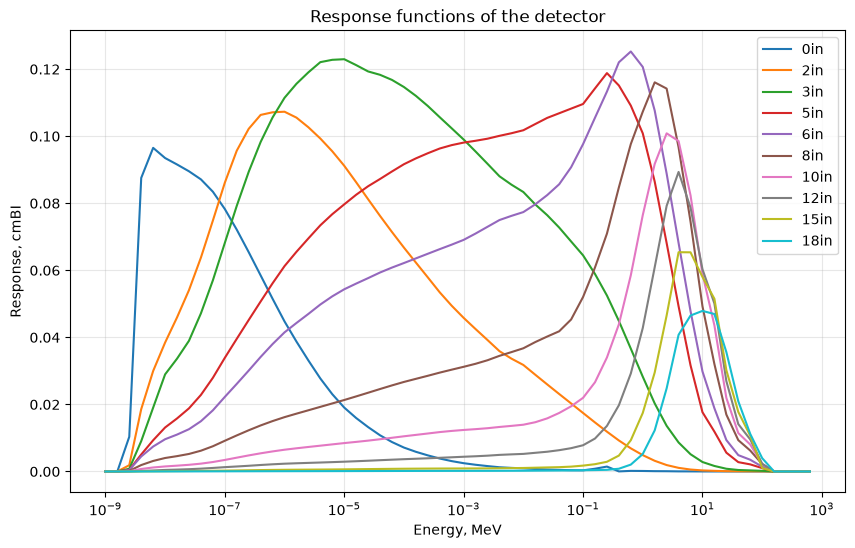

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bssunfold import Detector, RF_GSF
from bssunfold.utils.comparison import compare_spectra

detector = Detector(RF_GSF)
E = detector.E_MeV
names = detector.detector_names
print(f"Detector grid: {detector.n_energy_bins} bins, "
      f"{E[0]:.1e} - {E[-1]:.1f} MeV")
print("Spheres:", ", ".join(names))
detector.plot_response_functions()

## 2. IAEA Compendium reference spectrum -> detector readings

The compendium CSV stores 61-point Monte-Carlo spectra on its own energy
grid, which differs slightly from the 60-bin detector grid, so the
ground truth is interpolated onto the detector grid *for evaluation
only*.  The readings are the spectrum folded with the response
functions.

In [3]:
reference_csv = pd.read_csv(
    '../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv'
)
print(f"Reference CSV: {len(reference_csv)} rows, "
      f"{len(reference_csv.columns) - 1} spectra, "
      f"{reference_csv['E_MeV'].min():.1e} - "
      f"{reference_csv['E_MeV'].max():.0f} MeV")

SPECTRUM = 't4-14-s.txt_1'   # IAEA Compendium BSA benchmark case

readings = detector.get_effective_readings_for_spectra(
    reference_csv[['E_MeV', SPECTRUM]]
)
print("Effective readings:")
for name, val in readings.items():
    print(f"  {name:>4s}: {val:.4f}")

# Interpolate ground truth onto detector grid for evaluation
phi_true = np.interp(
    E, reference_csv['E_MeV'], reference_csv[SPECTRUM]
)

# Active energy bins for plotting
Emax = 20.0
active = E <= Emax
E_active = E[active]
phi_true_active = phi_true[active]

Reference CSV: 61 rows, 20 spectra, 1.0e-09 - 631 MeV
Effective readings:
   0in: 0.0668
   2in: 0.0901
   3in: 0.1382
   5in: 0.1639
   6in: 0.1407
   8in: 0.0805
  10in: 0.0392
  12in: 0.0179
  15in: 0.0064
  18in: 0.0031


## 3. Interval regularization idea (Shary 2017)

The point response matrix `A` of the unfolding problem is severely
ill-conditioned. *Interval regularization* embeds it into an interval
family by **inflating** the matrix:

- `inflation="shift"` — `[A] = A + [-tau, tau] I`: the Lavrentiev shift
  applied in *all directions at once*;
- `inflation="relative"` — every element widened by `tau * |a_ij|`.

The regularized spectrum is the maximizer (pseudo-solution) of Shary's
recognizing functional Tol over the inflated family, computed exactly
by one LP. As `tau -> 0` the estimate becomes the Chebyshev solution
(minimax fit) of the point system; growing `tau` *shrinks* the tolerable
set `Xi_tol` (more stability) while *expanding* the united set
`Xi_uni`. The choice of `tau` is an open question, analogous to
selecting the shift in classical Lavrentiev regularization — the method
reports a `tau_grid` sweep for that purpose.

> С. П. Шарый. Интервальная регуляризация для систем линейных
> алгебраических уравнений. — 2017/2018. See also Даженов, Зябин,
> Кумков, Шарый. Обработка и анализ интервальных данных. — 2024.

## 4. Baseline regularized unfolding

`tau = 0.02` shift inflation, reading intervals at 5 %:

In [4]:
result = detector.unfold_interval_regularization(
    readings, noise_level=0.05, tau=0.02, inflation="shift",
)
print(f"method = {result['method']}, tau = {result['tau']}, "
      f"inflation = {result['inflation']}")
print(f"tol_max = {result['tol_max']:.6f}  "
      f"({'compatible' if result['tol_max'] >= 0 else 'EMPTY Xi_tol'})")

grav = detector.unfold_gravel(
    readings, initial_spectrum=np.full(E.size, 0.5), max_iterations=2000)
mlem = detector.unfold_mlem(
    readings, initial_spectrum=np.full(E.size, 0.5), max_iterations=2000)

print(f"{'method':<28s} {'score':>8s}")
print("-" * 38)
for label, spec in [
    ("IntervalRegularization", result["spectrum"]),
    ("GRAVEL", grav["spectrum"]),
    ("MLEM", mlem["spectrum"]),
]:
    m = compare_spectra(phi_true, spec, metrics=["comprehensive_score"])
    print(f"{label:<28s} {m['comprehensive_score']:>8.3f}")

method = IntervalRegularization, tau = 0.02, inflation = shift
tol_max = 0.000154  (compatible)
method                          score
--------------------------------------
IntervalRegularization          2.295
GRAVEL                          2.954
MLEM                            1.519


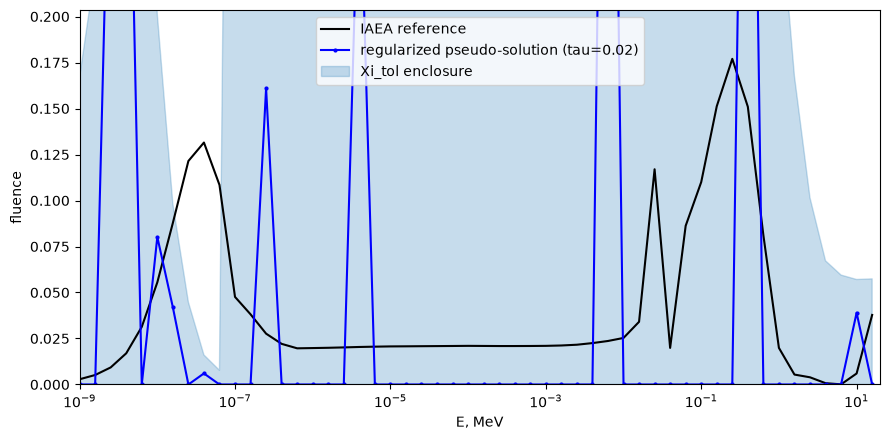

In [5]:
plt.figure(figsize=(9, 4.5))
plt.semilogx(E_active, phi_true_active, "k-",
             label="IAEA reference")
plt.semilogx(E_active, result["spectrum"][active], "b.-", ms=4,
             label="regularized pseudo-solution (tau=0.02)")
plt.fill_between(E_active, result["spectrum_lower"][active],
                 result["spectrum_upper"][active], alpha=0.25,
                 color="tab:blue", label="Xi_tol enclosure")
plt.xlim(E_active[0], Emax)
plt.ylim(0, max(phi_true_active) * 1.15)
plt.xlabel("E, MeV"); plt.ylabel("fluence")
plt.legend(); plt.tight_layout(); plt.show()

## 5. Sweep over the regularization parameter tau

Widening the matrix family can only shrink `Xi_tol`, so the reserve
`tol_max` is **non-increasing** in `tau`. In this underdetermined 10 x 60
unfolding a diagonal shift touches only the first 10 columns and the
max-Tol vertex has `x_i = 0` there, so `tol_max` stays flat while the
minimax residual `||Ax - b||_inf` of the pseudo-solution reacts to `tau`
and shows how the fit is redistributed. Choosing `tau` remains a user
decision — as for the shift in Lavrentiev regularization:

In [6]:
sweep_result = detector.unfold_interval_regularization(
    readings, noise_level=0.05, tau=0.05,
    tau_grid=[0.0, 0.01, 0.02, 0.05, 0.1, 0.2],
)
print(f"{'tau':>6s} {'tol_max':>12s} {'||Ax-b||_inf':>14s}")
print("-" * 34)
for s in sweep_result["tau_sweep"]:
    print(f"{s['tau']:>6.2f} {s['tol_max']:>12.6f} "
          f"{s['residual_inf']:>14.5f}")

tol0 = detector.unfold_interval_tol(readings, noise_level=0.05)
print(f"\ntau = 0 equals the plain Tol LP reserve: "
      f"{abs(sweep_result['tau_sweep'][0]['tol_max'] - tol0['tol_max']) < 1e-6}")

   tau      tol_max   ||Ax-b||_inf
----------------------------------
  0.00     0.000154        0.00804
  0.01     0.000154        0.00804
  0.02     0.000154        0.00435
  0.05     0.000154        0.00514
  0.10     0.000154        0.00435
  0.20     0.000154        0.00676

tau = 0 equals the plain Tol LP reserve: True


## 6. Shift vs relative inflation

Relative inflation widens *every* matrix element, so it regularizes
much more aggressively: `tol_max` drops faster and can certify an empty
`Xi_tol` already at a few percent:

inflation       tol_max      width
----------------------------------
shift          0.000154    37.5388
relative       0.000093    43.9242


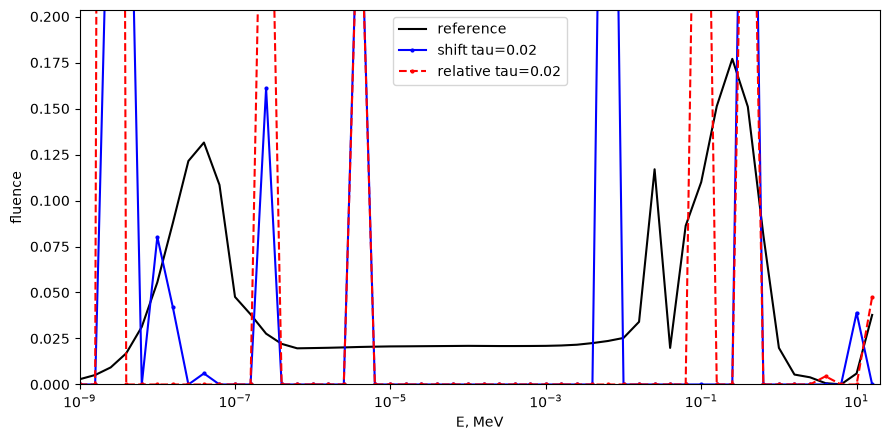

In [7]:
tau = 0.02
reg_shift = detector.unfold_interval_regularization(
    readings, noise_level=0.05, tau=tau, inflation="shift")
reg_rel = detector.unfold_interval_regularization(
    readings, noise_level=0.05, tau=tau, inflation="relative")

print(f"{'inflation':<10s} {'tol_max':>12s} {'width':>10s}")
print("-" * 34)
for label, r in [("shift", reg_shift), ("relative", reg_rel)]:
    w = float(np.sum(r["spectrum_upper"] - r["spectrum_lower"]))
    print(f"{label:<10s} {r['tol_max']:>12.6f} {w:>10.4f}")

plt.figure(figsize=(9, 4.5))
plt.semilogx(E_active, phi_true_active, "k-", label="reference")
plt.semilogx(E_active, reg_shift["spectrum"][active], "b.-", ms=4,
             label="shift tau=0.02")
plt.semilogx(E_active, reg_rel["spectrum"][active], "r.--", ms=4,
             label="relative tau=0.02")
plt.xlim(E_active[0], Emax)
plt.ylim(0, max(phi_true_active) * 1.15)
plt.xlabel("E, MeV"); plt.ylabel("fluence")
plt.legend(); plt.tight_layout(); plt.show()

## 7. Tolerable vs united set under inflation

Widening the matrix family **shrinks** the tolerable set `Xi_tol`
(strong, ∀-compatibility) but **expands** the united set `Xi_uni`
(weak, ∃-compatibility) — the two quantifiers react in opposite
directions. Compare the enclosure widths against the point-matrix
baseline:

In [8]:
base = detector.unfold_interval(readings, noise_level=0.05, tv_bound=20.0)
reg_tol = detector.unfold_interval_regularization(
    readings, noise_level=0.05, tau=0.05, inflation="shift",
    functional="tol", tv_bound=20.0)
reg_uss = detector.unfold_interval_regularization(
    readings, noise_level=0.05, tau=0.05, inflation="shift",
    functional="uss", tv_bound=20.0)

print(f"{'set':<6s} {'width':>10s} {'tol_max':>12s}")
print("-" * 30)
for label, r in [("Xi(A)", base), ("tol", reg_tol), ("uss", reg_uss)]:
    w = float(np.sum(r["spectrum_upper"] - r["spectrum_lower"]))
    tm = r.get("tol_max", float("nan"))
    print(f"{label:<6s} {w:>10.4f} {tm:>12.6f}")
print("The point-matrix baseline width lies between the inflated "
      "tolerable and united widths.")

set         width      tol_max
------------------------------
Xi(A)    167.1718          nan
tol      111.5026     0.000154
uss      342.7811     0.071568
The point-matrix baseline width lies between the inflated tolerable and united widths.


## 8. Smoothing the spiky vertex

The LP argmax of Tol is always a **vertex** of the max-Tol face — for an
ill-conditioned problem the vertex is spiky (a few bins carry the whole
estimate). This is intrinsic to recognizing-functionals, not an error:
the vertex still attains the maximal `tol_max`. To get a physically
readable spectrum, `smoothing=` picks a *smooth representative of the
same face*: minimize the first- (`"variation"`) or second-difference
(`"curvature"`) absolute sum subject to `Tol(x) >= tol_max` — still one
exact LP, and the tolerance level is unchanged. `face_slack` relaxes the
face constraint when the maximum face itself is too rigid:

smoothing      score       TV     curv     peak    tol_max
----------------------------------------------------------
none           0.520   0.4583   0.7556   0.1245   0.000154
variation      0.662   0.3347   0.5358   0.1240   0.000154
curvature      0.818   0.5637   0.1527   0.1592   0.000154


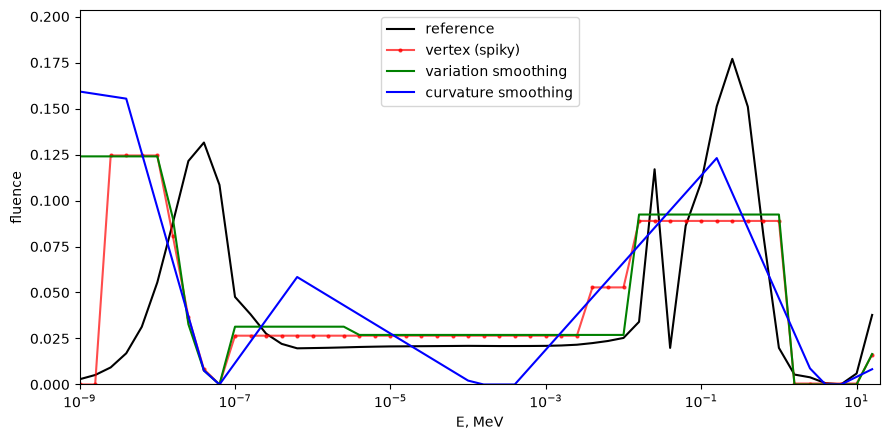

In [9]:
sm = {}
for mode in ["none", "variation", "curvature"]:
    sm[mode] = detector.unfold_interval_regularization(
        readings, noise_level=0.05, tau=0.02, tv_bound=20.0,
        smoothing=mode)

print(f"{'smoothing':<12s} {'score':>7s} {'TV':>8s} {'curv':>8s} "
      f"{'peak':>8s} {'tol_max':>10s}")
print("-" * 58)
for mode, r in sm.items():
    x = r["spectrum"]
    m = compare_spectra(phi_true, x, metrics=["comprehensive_score"])
    tv_x = float(np.sum(np.abs(np.diff(x))))
    curv = float(np.sum(np.abs(np.diff(x, n=2))))
    print(f"{mode:<12s} {m['comprehensive_score']:>7.3f} {tv_x:>8.4f} "
          f"{curv:>8.4f} {x.max():>8.4f} {r['tol_max']:>10.6f}")

plt.figure(figsize=(9, 4.5))
plt.semilogx(E_active, phi_true_active, "k-", lw=1.5, label="reference")
plt.semilogx(E_active, sm["none"]["spectrum"][active], "r.-", ms=4,
             alpha=0.7, label="vertex (spiky)")
plt.semilogx(E_active, sm["variation"]["spectrum"][active], "g-",
             label="variation smoothing")
plt.semilogx(E_active, sm["curvature"]["spectrum"][active], "b-",
             label="curvature smoothing")
plt.xlim(E_active[0], Emax)
plt.ylim(0, max(phi_true_active) * 1.15)
plt.xlabel("E, MeV"); plt.ylabel("fluence")
plt.legend(); plt.tight_layout(); plt.show()

In [10]:
relaxed = detector.unfold_interval_regularization(
    readings, noise_level=0.05, tau=0.02, tv_bound=20.0,
    smoothing="curvature", face_slack=0.5)
x_r = relaxed["spectrum"]
print(f"face_slack=0.5: TV={float(np.sum(np.abs(np.diff(x_r)))):.4f} "
      f"curv={float(np.sum(np.abs(np.diff(x_r, n=2)))):.4f} "
      f"score={compare_spectra(phi_true, x_r, metrics=['comprehensive_score'])['comprehensive_score']:.3f}")

face_slack=0.5: TV=0.5555 curv=0.1406 score=0.803


### 8b. Without the TV bound the effect is dramatic

The vertex of the *unregularized* face is the spiciest object (TV ~ 4.4).
Curvature smoothing keeps the same `tol_max` yet collapses the spikes —
no total-variation bound needed:

smoothing      score       TV     curv
--------------------------------------
none           2.295   4.4134   8.6220
curvature      0.756   0.5599   0.1684


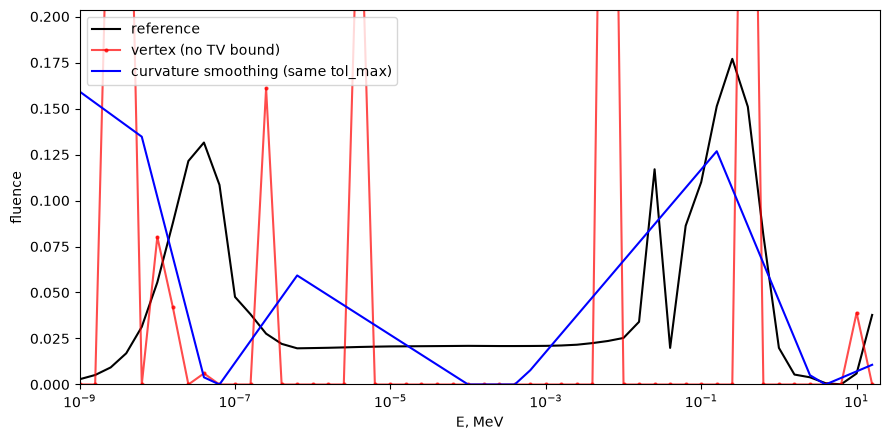

In [11]:
sp = {}
for mode in ["none", "curvature"]:
    sp[mode] = detector.unfold_interval_regularization(
        readings, noise_level=0.05, tau=0.02, smoothing=mode)

print(f"{'smoothing':<12s} {'score':>7s} {'TV':>8s} {'curv':>8s}")
print("-" * 38)
for mode, r in sp.items():
    x = r["spectrum"]
    m = compare_spectra(phi_true, x, metrics=["comprehensive_score"])
    tv_x = float(np.sum(np.abs(np.diff(x))))
    curv = float(np.sum(np.abs(np.diff(x, n=2))))
    print(f"{mode:<12s} {m['comprehensive_score']:>7.3f} {tv_x:>8.4f} "
          f"{curv:>8.4f}")

plt.figure(figsize=(9, 4.5))
plt.semilogx(E_active, phi_true_active, "k-", lw=1.5, label="reference")
plt.semilogx(E_active, sp["none"]["spectrum"][active], "r.-", ms=4,
             alpha=0.7, label="vertex (no TV bound)")
plt.semilogx(E_active, sp["curvature"]["spectrum"][active], "b-",
             label="curvature smoothing (same tol_max)")
plt.xlim(E_active[0], Emax)
plt.ylim(0, max(phi_true_active) * 1.15)
plt.xlabel("E, MeV"); plt.ylabel("fluence")
plt.legend(); plt.tight_layout(); plt.show()

### 8c. Relaxing the face: `face_slack` sweep

`face_slack` lowers the face constraint to
`Tol(x) >= (1 - face_slack) * tol_max`, buying extra smoothness at a
bounded loss of tolerance. `tol_at` below is the *actual* reserve of the
smoothed point, computed directly from the definition
`Tol(x) = min_i [rad(b_i) - |mid(b_i) - (Ax)_i| - rad(A_i) x]`:

In [12]:
A_sys = np.column_stack(
    [detector.sensitivities[n] for n in detector.detector_names]).T
b_sys = np.array([readings[n] for n in detector.detector_names])
b_lo_s, b_hi_s = np.maximum(b_sys * 0.95, 0.0), b_sys * 1.05
b_mid = (b_lo_s + b_hi_s) / 2.0
b_rad = (b_hi_s - b_lo_s) / 2.0
A_rad_002 = 0.02 * np.eye(*A_sys.shape)

def tol_at(x):
    reserve = b_rad - np.abs(b_mid - A_sys @ x) - A_rad_002 @ x
    return float(np.min(reserve))

print(f"{'slack':>6s} {'curv':>8s} {'TV':>8s} {'score':>7s} "
      f"{'tol_at':>10s} {'floor':>10s}")
print("-" * 62)
for slack in [0.0, 0.25, 0.5, 0.75]:
    r = detector.unfold_interval_regularization(
        readings, noise_level=0.05, tau=0.02, tv_bound=20.0,
        smoothing="curvature", face_slack=slack)
    x = r["spectrum"]
    m = compare_spectra(phi_true, x, metrics=["comprehensive_score"])
    curv = float(np.sum(np.abs(np.diff(x, n=2))))
    tv_x = float(np.sum(np.abs(np.diff(x))))
    floor = (1.0 - slack) * r["tol_max"]
    print(f"{slack:>6.2f} {curv:>8.4f} {tv_x:>8.4f} "
          f"{m['comprehensive_score']:>7.3f} {tol_at(x):>10.6f} "
          f"{floor:>10.6f}")

 slack     curv       TV   score     tol_at      floor
--------------------------------------------------------------
  0.00   0.1527   0.5637   0.818   0.000154   0.000154
  0.25   0.1465   0.5623   0.821   0.000116   0.000116
  0.50   0.1406   0.5555   0.803   0.000077   0.000077
  0.75   0.1346   0.5498   0.794   0.000039   0.000039


### 8d. Smoothed regularized solution vs classical baselines

The smoothed estimate is directly comparable with GRAVEL/MLEM (which
embed their own a-priori smoothing):

In [13]:
print(f"{'method':<28s} {'score':>8s}")
print("-" * 38)
for label, spec in [
    ("IntervalRegularization (vertex)", sm["none"]["spectrum"]),
    ("IntervalReg (variation)", sm["variation"]["spectrum"]),
    ("IntervalReg (curvature)", sm["curvature"]["spectrum"]),
    ("GRAVEL", grav["spectrum"]),
    ("MLEM", mlem["spectrum"]),
]:
    m = compare_spectra(phi_true, spec, metrics=["comprehensive_score"])
    print(f"{label:<28s} {m['comprehensive_score']:>8.3f}")

method                          score
--------------------------------------
IntervalRegularization (vertex)    0.520
IntervalReg (variation)         0.662
IntervalReg (curvature)         0.818
GRAVEL                          2.954
MLEM                            1.519


## 9. Takeaways

- Interval regularization turns the ill-conditioned point system into a
  stable interval problem: the estimate is the exact LP maximizer of the
  Tol functional over the inflated matrix family.
- `tau` is the regularization parameter; `tau = 0` recovers the
  Chebyshev (minimax) solution of the point system, the book's
  shrink-`Xi_tol` / expand-`Xi_uni` asymmetry is reproduced verbatim.
- The `tau_grid` sweep reports the `tol_max` / residual trade-off for
  selecting the inflation level — the choice of `tau` remains a
  user decision, exactly as in Lavrentiev's classical shift method
  (compare `unfold_lavrentiev`).
- Dose-rate bounds (`doserates_lower/upper`) come from the componentwise
  enclosure of the inflated tolerable set.
- The raw argmax-Tol vertex is spiky by nature; `smoothing="curvature"`
  or `"variation"` replaces it by a smooth point of the **same** max-Tol
  face (one extra LP, `tol_max` unchanged, the smoothed spectrum stays
  inside the guaranteed enclosure) — here the second-difference measure
  drops ~5x and the comprehensive score improves accordingly.